# pr-curve
run batear on recordings to get baseline 

Total segments: 1058 (positive: 1036, negative: 22)


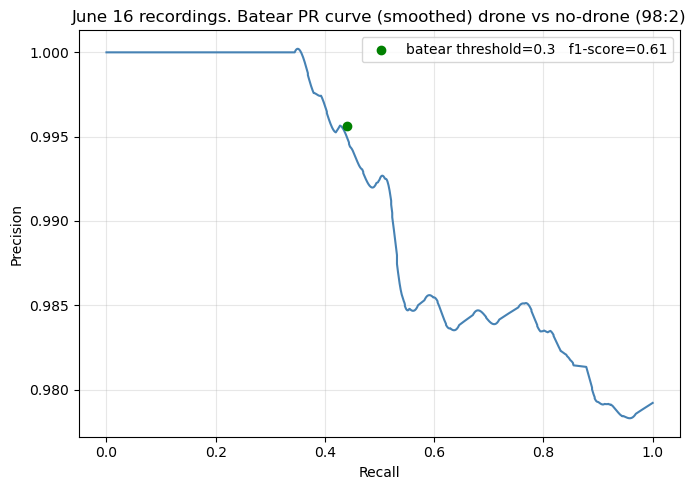

In [1]:
from audio_utils import segment_wav, plot_pr_curve, save_segments_as_wav
from audio_utils import scores_from_segments, SEG_SAMPLES, SR
from batear_detection import score_segment as batear_score_segment
from batear_detection import CONF_ON

import os

POS_DIR  = "sounds/drone"        # positive class (label=1)
NEG_DIR    = "sounds/no-drone"   # negative class (label=0)

def collect_wavs(folder):
    return [os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(".wav")]

all_segments = []

for path in collect_wavs(POS_DIR):
    all_segments.extend(segment_wav(path, label=1))

for path in collect_wavs(NEG_DIR):
    all_segments.extend(segment_wav(path, label=0))

print(f"Total segments: {len(all_segments)} "
      f"(positive: {sum(l for _, l in all_segments)}, "
      f"negative: {sum(1 for _, l in all_segments if l == 0)})")

save_segments_as_wav(all_segments, "segments")

batear_scores, batear_labels = scores_from_segments(all_segments, batear_score_segment, fs=SR)
#cnn_scores, labels = scores_from_segments(all_segments, cnn_score_segment, fs=SR)

fig = plot_pr_curve(batear_scores, batear_labels, threshold_label="batear threshold", title="June 16 recordings. Batear PR curve (smoothed) drone vs no-drone (98:2)", op_threshold=CONF_ON)
fig.savefig("images/batear_jun16_pr_curve_.png", dpi=150, bbox_inches="tight")